In [62]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [63]:
from matplotlib.colors import ListedColormap
cmap_bold= ListedColormap(["#FF0000","#0000FF"])
cmap_light= ListedColormap(["#FFBBBB","#BBBBFF"])

###  Useful function

In [64]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def cross_entropy(y, p_hat):
    # Binary cross-entropy loss
    return -(1/len(y)) * np.sum(y * np.log(p_hat + 1e-12) + (1 - y) * np.log(1 - p_hat + 1e-12))

### Import Dataset(Train)

In [66]:
df= pd.read_csv("aps_failure_training_set_processed_8bit.csv")

In [67]:
df.shape

(60000, 171)

In [68]:
df.isnull().sum()

class     0
aa_000    0
ab_000    0
ac_000    0
ad_000    0
         ..
ee_007    0
ee_008    0
ee_009    0
ef_000    0
eg_000    0
Length: 171, dtype: int64

In [69]:
df.head()

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,-0.992188,0.117188,-0.289062,0.992188,-0.007812,-0.046875,-0.054688,-0.007812,-0.03125,-0.054688,...,0.687500,0.515625,0.234375,0.070312,0.007812,-0.109375,-0.140625,-0.171875,-0.023438,-0.023438
1,-0.992188,-0.179688,-0.289062,-0.468750,-0.007812,-0.046875,-0.054688,-0.007812,-0.03125,-0.054688,...,-0.023438,-0.062500,-0.132812,-0.132812,-0.187500,-0.148438,-0.085938,-0.140625,-0.023438,-0.023438
2,-0.992188,-0.125000,-0.289062,-0.468750,-0.007812,-0.046875,-0.054688,-0.007812,-0.03125,-0.054688,...,-0.140625,-0.093750,-0.015625,0.015625,-0.007812,-0.109375,-0.093750,-0.164062,-0.023438,-0.023438
3,-0.992188,-0.406250,-0.289062,-0.468750,-0.007812,-0.046875,-0.007812,-0.007812,-0.03125,-0.054688,...,-0.382812,-0.382812,-0.375000,-0.351562,-0.312500,-0.195312,-0.304688,-0.171875,0.890625,0.992188
4,-0.992188,0.007812,-0.289062,-0.468750,-0.007812,-0.046875,-0.054688,-0.007812,-0.03125,-0.054688,...,0.156250,0.031250,-0.031250,-0.039062,-0.046875,-0.015625,0.656250,-0.148438,-0.023438,-0.023438


In [70]:
df.tail()

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
59995,-0.992188,0.640625,0.007812,-0.468750,-0.007812,-0.046875,-0.054688,-0.007812,-0.03125,-0.054688,...,0.476562,0.656250,0.718750,0.734375,0.640625,0.218750,0.992188,0.421875,-0.023438,-0.023438
59996,-0.992188,-0.390625,-0.289062,0.992188,-0.007812,-0.046875,-0.054688,-0.007812,-0.03125,-0.054688,...,-0.375000,-0.375000,-0.359375,-0.289062,-0.312500,-0.195312,-0.304688,-0.171875,-0.023438,-0.023438
59997,-0.992188,-0.406250,-0.289062,0.992188,-0.007812,-0.046875,-0.054688,-0.007812,-0.03125,-0.054688,...,-0.382812,-0.382812,-0.375000,-0.351562,-0.312500,-0.195312,-0.304688,-0.171875,-0.023438,-0.023438
59998,-0.992188,0.140625,0.304688,0.992188,-0.007812,-0.046875,-0.054688,-0.007812,-0.03125,-0.054688,...,0.218750,0.023438,-0.085938,-0.148438,-0.132812,-0.101562,0.992188,0.992188,-0.023438,-0.023438
59999,-0.992188,-0.132812,0.281250,-0.468750,-0.007812,-0.046875,-0.054688,-0.007812,-0.03125,-0.054688,...,-0.007812,-0.046875,-0.085938,-0.125000,-0.101562,-0.109375,0.070312,-0.171875,-0.023438,-0.023438


##### For Logistics regression and fasther mathematical operations, conversion of dataframe to numpy is better

In [79]:
df = df.to_numpy()

In [80]:
y = df[:,0]
X = df[:,1:]

In [81]:
y

array([-0.9921875, -0.9921875, -0.9921875, ..., -0.9921875, -0.9921875,
       -0.9921875], shape=(60000,))

In [82]:
y = pd.Series(y).map({-0.9921875: 0, 0.9921875: 1}).values

In [83]:
X

array([[ 0.1171875, -0.2890625,  0.9921875, ..., -0.171875 , -0.0234375,
        -0.0234375],
       [-0.1796875, -0.2890625, -0.46875  , ..., -0.140625 , -0.0234375,
        -0.0234375],
       [-0.125    , -0.2890625, -0.46875  , ..., -0.1640625, -0.0234375,
        -0.0234375],
       ...,
       [-0.40625  , -0.2890625,  0.9921875, ..., -0.171875 , -0.0234375,
        -0.0234375],
       [ 0.140625 ,  0.3046875,  0.9921875, ...,  0.9921875, -0.0234375,
        -0.0234375],
       [-0.1328125,  0.28125  , -0.46875  , ..., -0.171875 , -0.0234375,
        -0.0234375]], shape=(60000, 170))

In [84]:
y

array([0, 0, 0, ..., 0, 0, 0], shape=(60000,))

### Binomial Logistic Regression

In [16]:
class LogisticRegression():
    def __init__(self, thresh=0.5):
        self.thresh = thresh
        self.w = None
        self.b = None

    def fit(self, X, y, eta=1e-3, epose=1e3, show_curve=True):
        epose = int(epose)
        N, D = X.shape   # N=observations, D=features

        # Random initialization of weights and bias
        self.w = np.random.randn(D)
        self.b = np.random.randn(1)

        # Container for loss
        J = np.zeros(epose)

        # Gradient Descent
        for epoch in range(epose):
            p_hat = self.__forward__(X)
            J[epoch] = cross_entropy(y, p_hat)

            # Update rules
            self.w -= eta * (1/N) * X.T @ (p_hat - y)
            self.b -= eta * (1/N) * np.sum(p_hat - y)

        if show_curve:
            plt.figure()
            plt.plot(J, color="red")
            plt.xlabel("Epochs")
            plt.ylabel("Cross-Entropy Loss")
            plt.title("Training Curve")
            plt.show()

    def __forward__(self, X):
        return sigmoid(X @ self.w + self.b)

    def predicts(self, X):
        return (self.__forward__(X) >= self.thresh).astype(np.int32)

    def evaluate(self, X, y_true):
        y_pred = self.predicts(X)
        acc = accuracy_score(y_true, y_pred)
        print("\nEvaluation Results")
        print(f"Accuracy: {acc:.4f}")
        print("\nClassification Report:")
        print(classification_report(y_true, y_pred))
        cm = confusion_matrix(y_true, y_pred)
        ConfusionMatrixDisplay(cm).plot(cmap="Blues")
        plt.show()


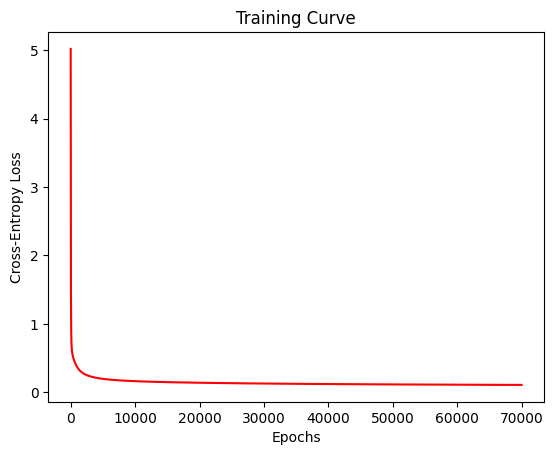


Evaluation Results
Accuracy: 0.9593

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     11788
           1       0.29      0.92      0.44       212

    accuracy                           0.96     12000
   macro avg       0.65      0.94      0.71     12000
weighted avg       0.99      0.96      0.97     12000



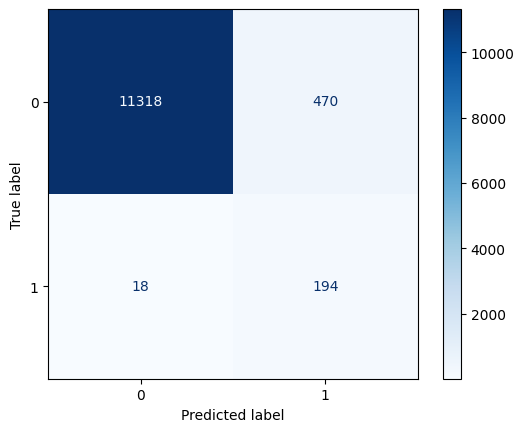

In [19]:
# log_reg.fit(X, y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#Balance the training data with SMOTE

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)


# Train model
model = LogisticRegression(thresh=0.5)
model.fit(X_train, y_train, eta=1e-2, epose=7e4)

# Evaluate
model.evaluate(X_test, y_test)

## Naive Bayes 

In [20]:
from scipy.stats import multivariate_normal as nvm

In [140]:
class GaussNB():
  def fit(self, X, y, epsilon = 7e-1):
    self.likelihoods = dict()
    self.priors = dict()
    self.K = set(y.astype(int)) # K = Classes

    for k in self.K:
      X_k = X[y==k]
      self.likelihoods[k] = {'mean': X_k.mean(axis=0), 'cov': X_k.var(axis=0) + epsilon} # axis=0 --> observations(rows), cov = Covariance
      self.priors[k] = len(X_k)/len(X)
  def predict(self, X):
    N, D = X.shape
    P_hat = np.zeros((N, len(self.K)))

    for k, l in self.likelihoods.items():
      P_hat[:,k] = nvm.logpdf(X, l['mean'], l['cov']) + np.log(self.priors[k])
    return P_hat.argmax(axis=1)

In [141]:
def accuracy(y, y_hat):
  return np.mean(y == y_hat)

def evaluate(self, X, y_true):
    y_pred = self.predict(X)

In [142]:
gnb = GaussNB()

In [143]:
gnb.fit(X,y)

In [144]:
#Training accuracy

In [145]:
y_hat = gnb.predict(X)

In [146]:
accuracy(y, y_hat)

np.float64(0.9370833333333334)

In [147]:
acc = accuracy_score(y, y_hat)
prec = precision_score(y, y_hat)
rec = recall_score(y, y_hat)
f1 = f1_score(y, y_hat)

print("=== APS Naive Bayes Model Performance ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}\n")

=== APS Naive Bayes Model Performance ===
Accuracy : 0.9371
Precision: 0.1899
Recall   : 0.8500
F1-Score : 0.3105



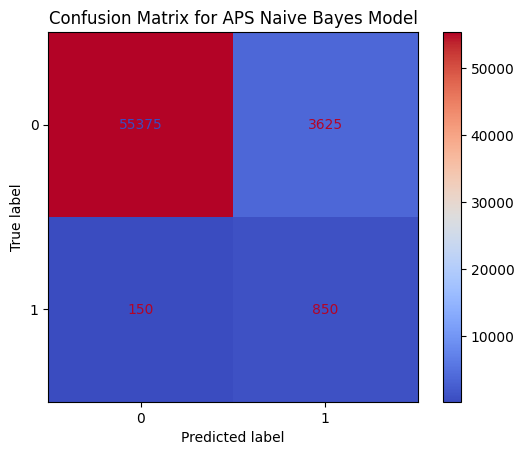

In [148]:
cm = confusion_matrix(y, y_hat)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="coolwarm", values_format=".0f")
plt.title("Confusion Matrix for APS Naive Bayes Model")
plt.show()

### Random Binary Classifier

In [40]:
def CoinFlip(y):
  y_hat = np.zeros(len(y))
  for i in range(len(y)):
    flip = np.random.randn(1)
    if flip > 0:
      y_hat[i] = 1
  return y_hat

In [41]:
accuracy(y, CoinFlip(y))

np.float64(0.49955)

In [42]:
## Data Visualization

## Some Data Visualization between the features

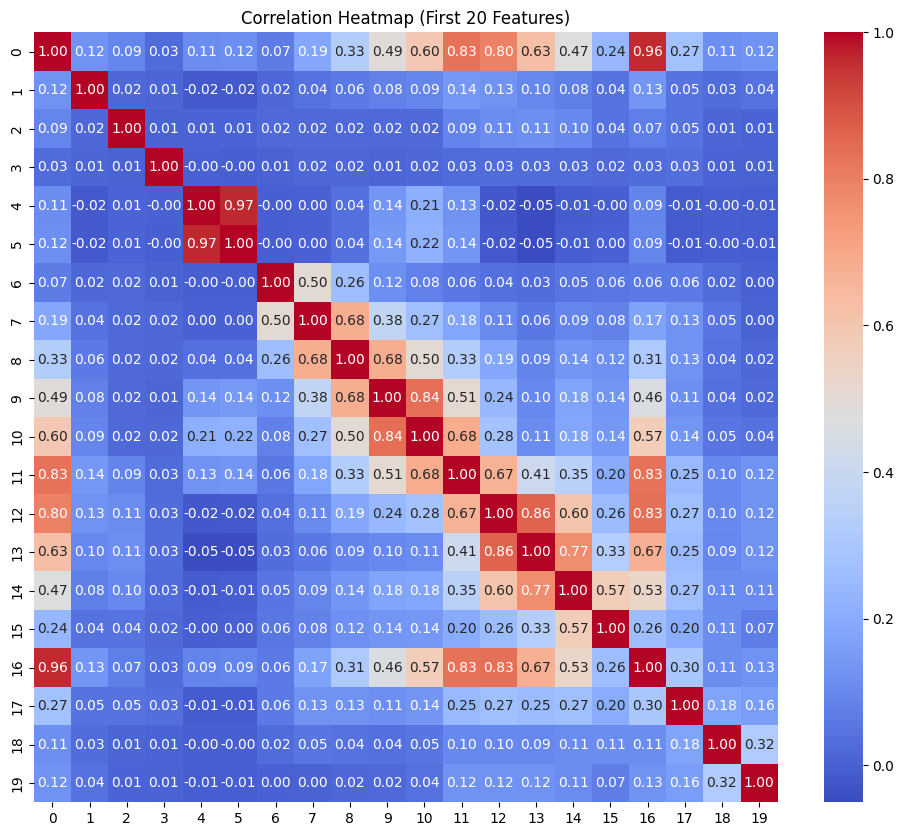

In [43]:
subset = pd.DataFrame(X[:, :20])  # convert NumPy array back to DataFrame
plt.figure(figsize=(12,10))
sns.heatmap(subset.corr(), cmap="coolwarm", annot=True, fmt=".2f", cbar=True)
plt.title("Correlation Heatmap (First 20 Features)")
plt.show()


### KDE plot for comparing class distributions on first feature
##### Distribution of classes on the features


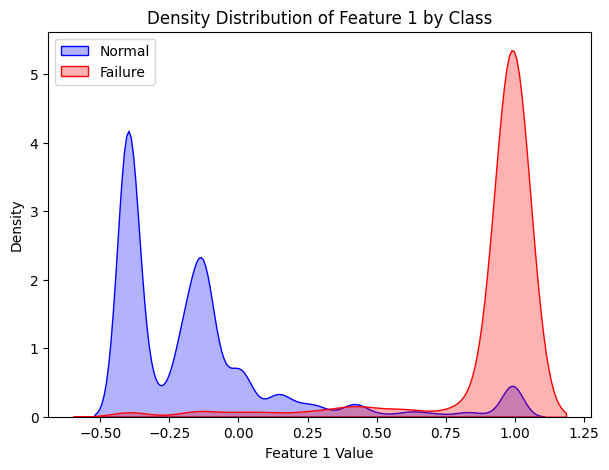

In [44]:
df = pd.DataFrame(X)
df['label'] = y
plt.figure(figsize=(7,5))
sns.kdeplot(x=df[0][df['label']==0], label="Normal", fill=True, alpha=0.3, color="blue")
sns.kdeplot(x=df[0][df['label']==1], label="Failure", fill=True, alpha=0.3, color="red")
plt.title("Density Distribution of Feature 1 by Class")
plt.xlabel("Feature 1 Value")
plt.ylabel("Density")
plt.legend()
plt.show()